# Bitcoin Sentiment Trader Analysis

This notebook contains the primary analysis for Bitcoin sentiment and trading strategies.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_preprocessing import run_pipeline
from src.feature_engineering import build_features
from src.analysis import run_all_analysis

In [3]:
from src.data_preprocessing import load_sentiment, load_trades

sentiment = load_sentiment()
trades = load_trades()

print("Sentiment dates:", sentiment["date"].min(), "→", sentiment["date"].max())
print("Trades dates:", trades["date"].min(), "→", trades["date"].max())

[warn] No leverage column → defaulting to 1x
Sentiment dates: 2018-02-01 00:00:00 → 2025-05-02 00:00:00
Trades dates: NaT → NaT


In [4]:
import pandas as pd

df = pd.read_csv("../data/raw/hyperliquid_trades.csv")
print(df.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']


In [5]:
# Normalize column names first
df.columns = df.columns.str.strip().str.lower()

# Explicit rename mapping based on your dataset
rename = {
    "account": "account",
    "coin": "symbol",
    "execution price": "price",
    "size usd": "size",          # use USD size
    "side": "side",
    "timestamp": "time",         # use this (not IST unless needed)
    "closed pnl": "pnl",
}

df.rename(columns=rename, inplace=True)

In [6]:
# Ensure required columns exist

if "leverage" not in df.columns:
    print("[warn] No leverage column → defaulting to 1x")
    df["leverage"] = 1

if "pnl" not in df.columns:
    raise ValueError("PnL column not found — check dataset")

if "time" not in df.columns:
    raise ValueError("Time column not found — check dataset")

[warn] No leverage column → defaulting to 1x


In [7]:
df["time"] = pd.to_datetime(df["time"], errors="coerce")
df.dropna(subset=["time"], inplace=True)
df["date"] = df["time"].dt.normalize()

In [8]:
df["is_win"] = (df["pnl"] > 0).astype(int)

In [9]:
import pandas as pd
import os

# Check sentiment CSV
sent = pd.read_csv("../data/raw/bitcoin_sentiment.csv")
print("=== SENTIMENT COLUMNS ===")
print(sent.columns.tolist())
print(sent.head(2))

print()

# Check trades CSV
trades = pd.read_csv("../data/raw/hyperliquid_trades.csv")
print("=== TRADES COLUMNS ===")
print(trades.columns.tolist())
print(trades.head(2))

=== SENTIMENT COLUMNS ===
['timestamp', 'value', 'classification', 'date']
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02

=== TRADES COLUMNS ===
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0

In [10]:
import pandas as pd
import os

path = r"C:\Projects\Bitcoin-Sentiment-Trader-Analysis\data\raw\bitcoin_sentiment.csv"
df = pd.read_csv(path)

print("=== BEFORE rename ===")
print(df.columns.tolist())

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("\n=== AFTER normalize ===")
print(df.columns.tolist())
print("\nFirst 2 rows:")
print(df.head(2))

=== BEFORE rename ===
['timestamp', 'value', 'classification', 'date']

=== AFTER normalize ===
['timestamp', 'value', 'classification', 'date']

First 2 rows:
    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02


In [11]:
merged = run_pipeline()
merged.head()

Loading sentiment …
  → 2644 rows | 2018-02-01 to 2025-05-02
Loading trades …
[warn] No leverage column → defaulting to 1x
  → 0 rows
Merging …
[merge] Kept 0/0 rows after sentiment join.
[save] Written → c:\Projects\Bitcoin-Sentiment-Trader-Analysis\src\..\data\processed\merged_data.csv


,account,symbol,price,size_size_tokens,size,side,time,start_position,direction,pnl,...,crossed,fee,trade_id,timestamp,leverage,date,is_win,sentiment,is_fear,fear_greed_value


In [12]:
df = build_features(merged)
df.head()

Building daily features …
Adding sentiment shift flags …
Classifying trader profiles …
Computing risk features …
Feature set ready: 0 rows × 23 cols


,date,account,total_pnl,mean_pnl,trade_count,win_count,avg_leverage,max_leverage,avg_size,total_volume,...,prev_sentiment,sentiment_shift,fear_to_greed,greed_to_fear,trader_tier,lifetime_pnl,avg_win_rate,total_trades,sharpe_ratio,is_overleveraged



📊 Generating plots …
  ✓ 01_pnl_vs_sentiment.png
  ✓ 02_winrate_vs_sentiment.png


ValueError: Dimensions of labels and X must be compatible

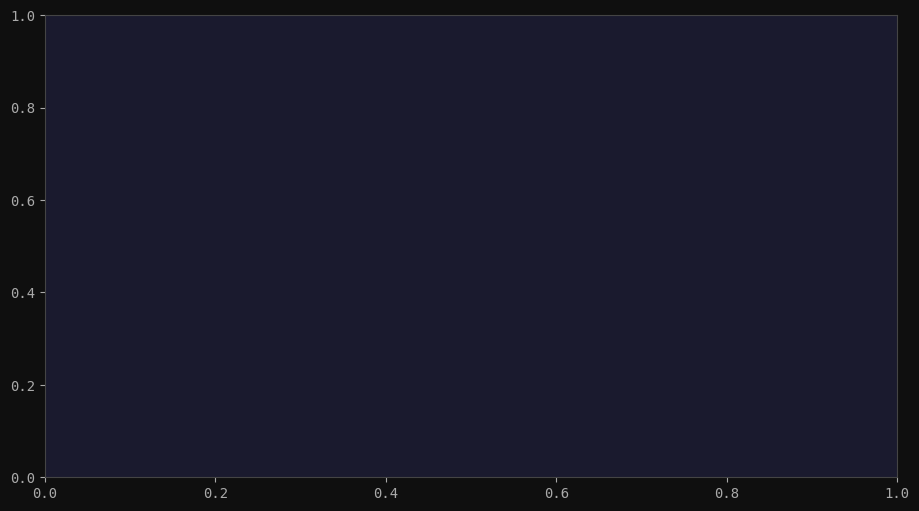

In [13]:
results = run_all_analysis(df)
results

In [ ]:
df.to_csv("../outputs/results.csv", index=False)